In [2]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
import sys, os
import time

current_dir = os.getcwd()
package_dir = current_dir + '/packages'
sys.path.append(package_dir)

import crydberg as rd

# Generating system

In [135]:
N = 10
n_networks = 100
n_thermalSamples = 1
n_samples = n_networks*n_thermalSamples
K = 1

systems = rd.MagneticSystem(N, n_samples, K=K) # generating system
systems.align_m() # randomizing initial spin config. m0
systems.m = cp.broadcast_to(systems.m[0], (n_samples, N, 3)) # copying one m0 throughout all samples

# setting Js of thermal samples batches with one J
J_toSet = []
for J in systems.J[:n_networks]:
    J_toSet.append(cp.broadcast_to(J, (n_thermalSamples, N, N)))
J_toSet = cp.array(J_toSet)
J_toSet = J_toSet.reshape(n_samples, N, N)
systems.J = J_toSet
del J_toSet # deleting buffer

# Running dynamics

In [144]:
dt = 0.1
n_burnSteps = 20000
n_steps = 100
T = 0.0

steps = cp.arange(n_steps)

# storing initial spins
m0 = systems.m
m0 = m0.reshape(n_networks, n_thermalSamples, N, 3)
m0 = cp.broadcast_to(m0[cp.newaxis, :, :, :, :], (n_steps, n_networks, n_thermalSamples, N, 3))

# burning-in system
progress_bar = 0
for i in range(n_burnSteps):
    systems.LLG_1stepSIB(dt, alpha=1, precession=0, T=T)
    print(f'\rProgress: {100*i/n_burnSteps}%    ', end='')

history = []
for i in range(n_steps):
    history.append(systems.m)
    systems.LLG_1stepSIB(dt, alpha=1, precession=0, T=T)
history = cp.array(history).reshape(n_steps, n_networks, n_thermalSamples, N, 3)
print('\rDone.            ')

Done.                


# Correlation

In [145]:
# calculating correlation
corr = cp.mean(history*m0, axis=(1,2,3))

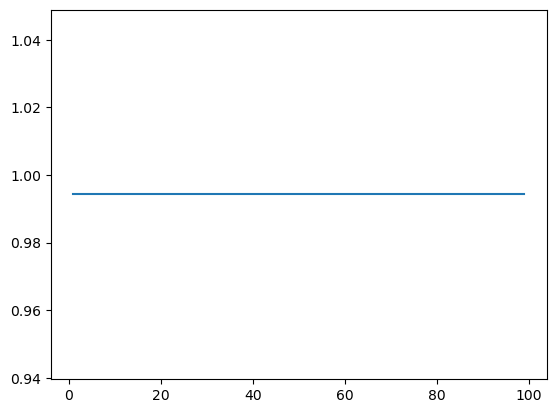

In [146]:
l,r = 1, None
plt.plot(steps.get()[l:r], corr.get()[l:r,2])

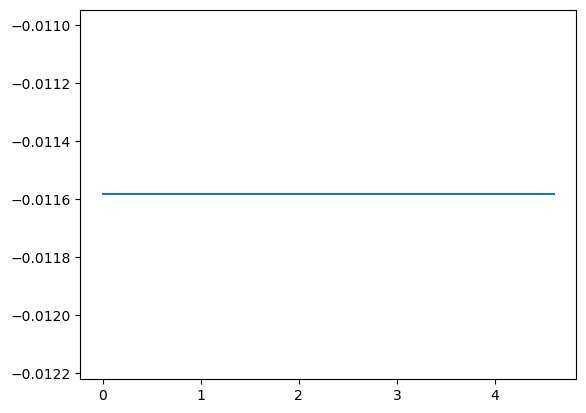

In [147]:
l,r = 1, None
plt.plot(cp.log(steps[l:r]).get(), cp.log(corr[l:r,2]**2).get())

# Edwards-Anderson parameter

In [148]:
q2 = cp.mean(history**2, axis=(1,2,3))

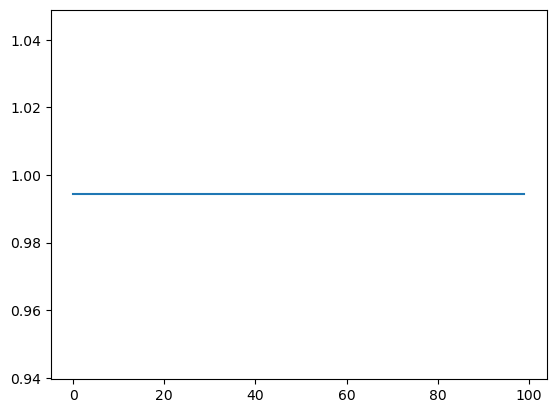

In [149]:
plt.plot(q2.get()[:,2])

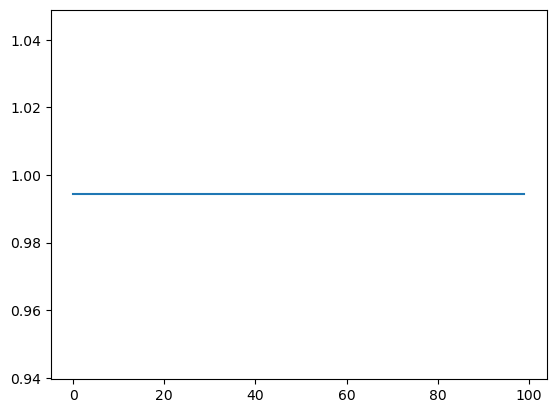

In [141]:
plt.plot(q2.get()[:,2])

In [142]:
EA = cp.mean(cp.mean(history, axis=2)**2, axis=(1,2))

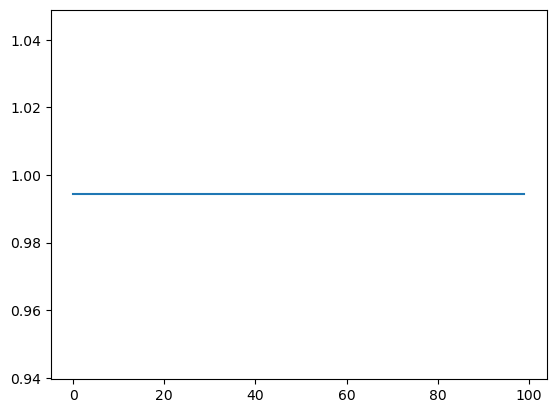

In [143]:
plt.plot(EA.get()[:,2])

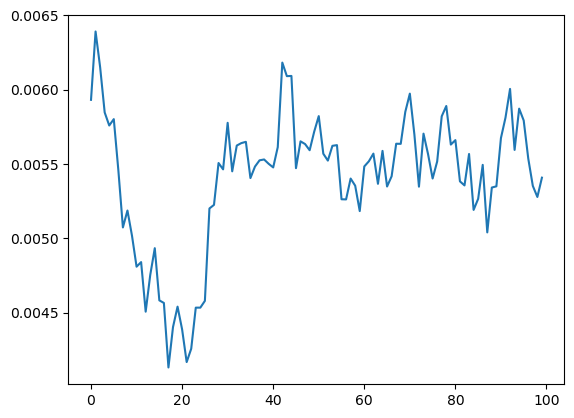

In [105]:
plt.plot(EA.get()[:,2])

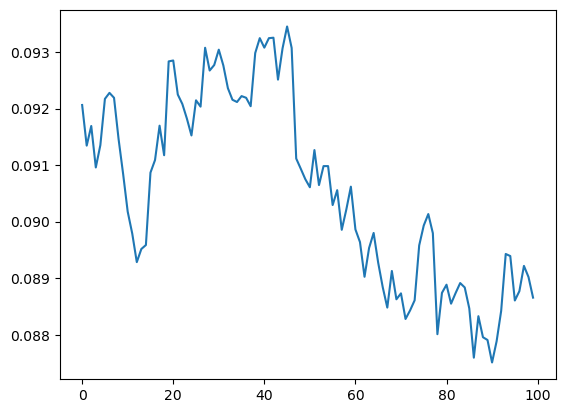

In [98]:
plt.plot(EA.get()[:,2])

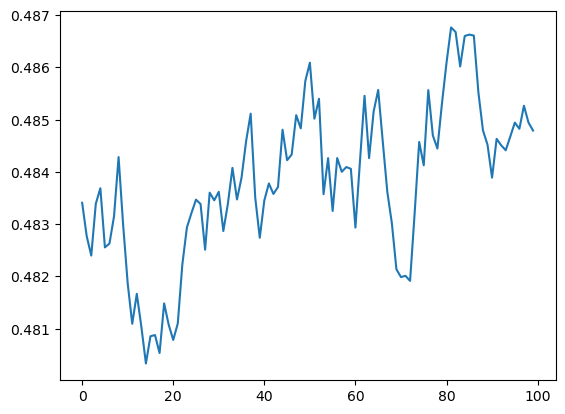

In [91]:
plt.plot(EA.get()[:,2])

In [31]:
history.shape

(100, 100, 200, 10, 3)

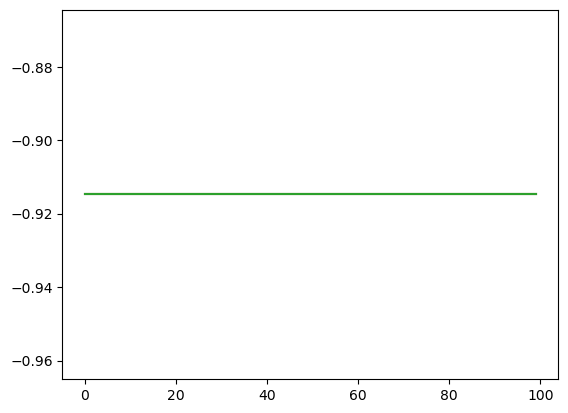

In [134]:
plt.plot(history.get()[:,0,0,7,2])
plt.plot(history.get()[:,0,1,7,2])
plt.plot(history.get()[:,0,2,7,2])

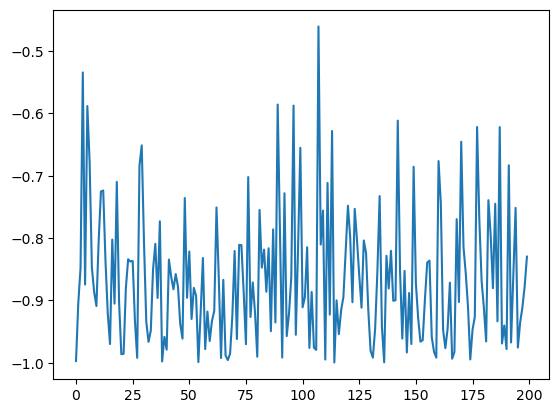

In [35]:
plt.plot(history.get()[-1,0,:,0,2])